# Clasificación: SVM y el Truco del Kernel

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/03_clasificacion_svm_y_kernels.ipynb)

## Objetivos


- Comprender la intuición geométrica detrás de las Máquinas de Vectores de Soporte (SVM) y el concepto de "Margen Máximo".
- Desmitificar el *Kernel Trick*: cómo resolver problemas no lineales proyectando datos a dimensiones superiores sin explotar la memoria RAM.
- Analizar el costo computacional de entrenamiento de SVM ($O(n^2)$ a $O(n^3)$) y entender por qué no es viable para datasets masivos.



## Prerrequisitos


- Entendimiento de fronteras de decisión lineales.
- Haber completado: [Clasificación: Modelos Lineales y Basados en Distancias](02_clasificacion_lineal_y_distancias.ipynb).

---



## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica



En el notebook anterior, vimos que la Regresión Logística traza una línea recta para separar dos clases. Pero, si dos clases son perfectamente separables por una línea, en realidad existen **infinitas líneas** que pueden separarlas.

¿Cuál de todas esas líneas es la "mejor"?



### El Margen Máximo y los Vectores de Soporte



La filosofía de las **Máquinas de Vectores de Soporte (SVM)** es encontrar la línea (o hiperplano) que no solo separe las clases, sino que pase **lo más lejos posible** de los puntos más cercanos de ambas clases. A esta distancia de seguridad se le llama **Margen**.

Los puntos de datos que caen exactamente en el borde de este margen se denominan **Vectores de Soporte**. Son los únicos puntos que le importan al algoritmo; si se eliminan todos los demás datos del dataset, la frontera de decisión no cambiaría en absoluto.

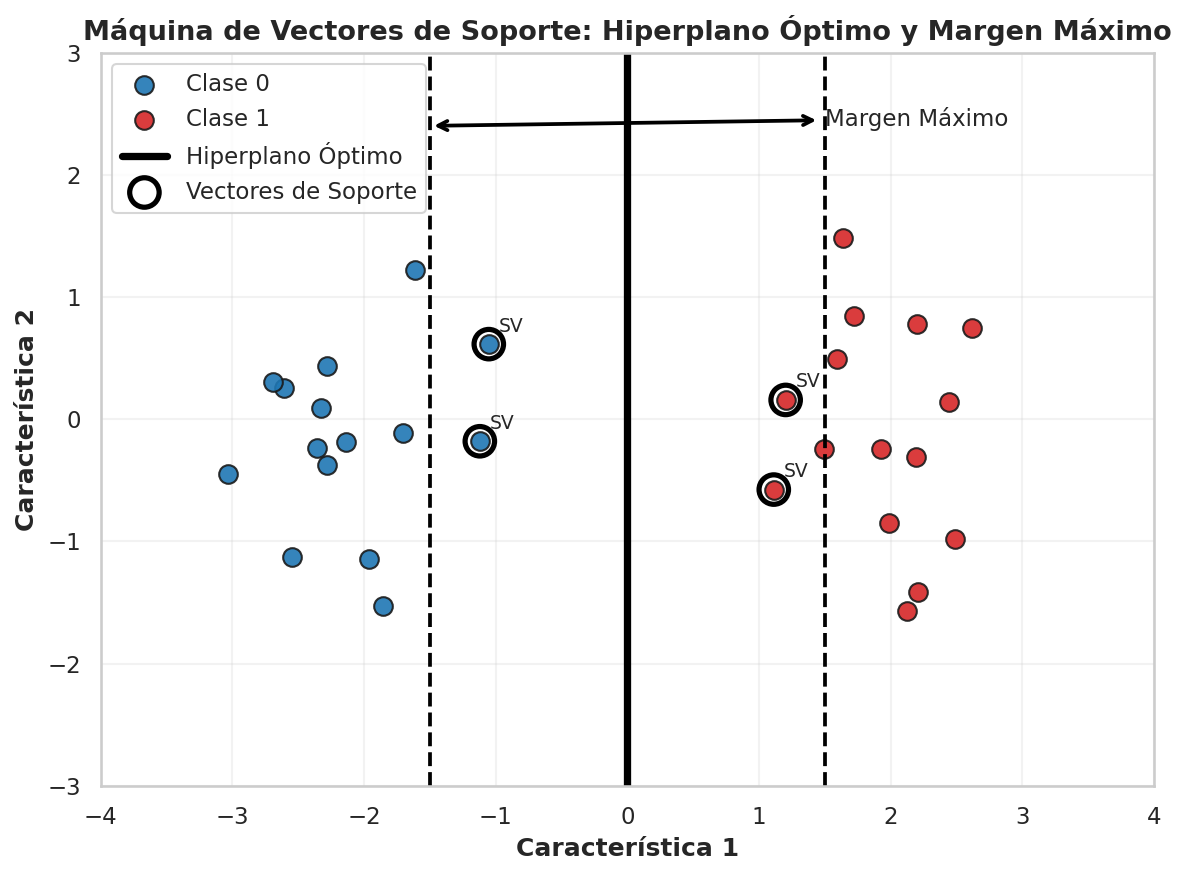

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Generación de datos
# -------------------------
np.random.seed(42)

# Clase 0 (azul)
X0 = np.random.normal(loc=[-2, 0], scale=[0.6, 0.8], size=(15, 2))

# Clase 1 (rojo)
X1 = np.random.normal(loc=[2, 0], scale=[0.6, 0.8], size=(15, 2))

# -------------------------
# Definición de hiperplano y margen
# (para visualización conceptual)
# -------------------------
x_vals = np.linspace(-4, 4, 200)

# Hiperplano central
w = np.array([1, 0])  # orientación vertical conceptual
b = 0

y_center = x_vals*0 + 0

# Líneas de margen
margin = 1.5
y_margin_top = y_center + margin
y_margin_bottom = y_center - margin

# -------------------------
# Selección de vectores de soporte (conceptual)
# -------------------------
# elegimos los puntos más cercanos al hiperplano
dist0 = np.abs(X0[:,0])
dist1 = np.abs(X1[:,0])

sv0 = X0[np.argsort(dist0)[:2]]
sv1 = X1[np.argsort(dist1)[:2]]

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8,6))

# Puntos
plt.scatter(X0[:,0], X0[:,1],
            color="#1f77b4",
            s=80,
            label="Clase 0",
            edgecolor="k",
            alpha=0.9)

plt.scatter(X1[:,0], X1[:,1],
            color="#d62728",
            s=80,
            label="Clase 1",
            edgecolor="k",
            alpha=0.9)

# Hiperplano
plt.plot([0,0], [-3,3],
         color="black",
         linewidth=3.5,
         label="Hiperplano Óptimo")

# Márgenes
plt.plot([-margin,-margin], [-3,3],
         linestyle="--",
         color="black",
         linewidth=1.8)

plt.plot([margin,margin], [-3,3],
         linestyle="--",
         color="black",
         linewidth=1.8)

# Vectores de soporte
sv = np.vstack((sv0, sv1))

plt.scatter(sv[:,0], sv[:,1],
            s=200,
            facecolors="none",
            edgecolors="black",
            linewidths=2.5,
            label="Vectores de Soporte")

# Flecha del margen
plt.annotate("Margen Máximo",
             xy=(-margin,2.4),
             xytext=(margin+0.7,2.4),
             arrowprops=dict(arrowstyle="<->", linewidth=1.8, color="black"),
             ha='center',
             fontsize=11)

# Etiqueta vectores soporte
for point in sv:
    plt.annotate("SV",
                 (point[0], point[1]),
                 textcoords="offset points",
                 xytext=(5,6),
                 fontsize=9)

# Estética tipo paper
plt.xlabel("Característica 1", fontsize=12)
plt.ylabel("Característica 2", fontsize=12)
plt.title("Máquina de Vectores de Soporte: Hiperplano Óptimo y Margen Máximo", fontsize=13)

plt.legend(frameon=True)
plt.grid(alpha=0.25)

plt.xlim(-4,4)
plt.ylim(-3,3)

plt.tight_layout()
plt.show()

### El Problema No Lineal y el *Kernel Trick*



¿Qué pasa si los datos no se pueden separar con una línea recta? Imaginemos, por ejemplo, un círculo de puntos rojos rodeado por un anillo de puntos azules. Ninguna línea recta en 2D puede separarlos.

La solución intuitiva sería crear una nueva característica matemática (por ejemplo, $z = x^2 + y^2$) que eleve los puntos rojos hacia arriba en un eje 3D, permitiéndonos cortarlos con un plano plano (una hoja de papel).

Sin embargo, calcular nuevas dimensiones para millones de puntos consume demasiada memoria y tiempo. En este punto, es en dónde entra en juego "la magia" matemática del **Kernel Trick**. Un *Kernel* es una función que calcula la relación (el producto punto) entre dos vectores en un espacio de alta dimensión **sin tener que transformar realmente los datos a ese espacio**.

Es como si el algoritmo pudiera "ver" en 3D o infinitas dimensiones, pero haciendo los cálculos en 2D.



## Desarrollo e Implementación



Vamos a visualizar este concepto usando un dataset sintético circular.



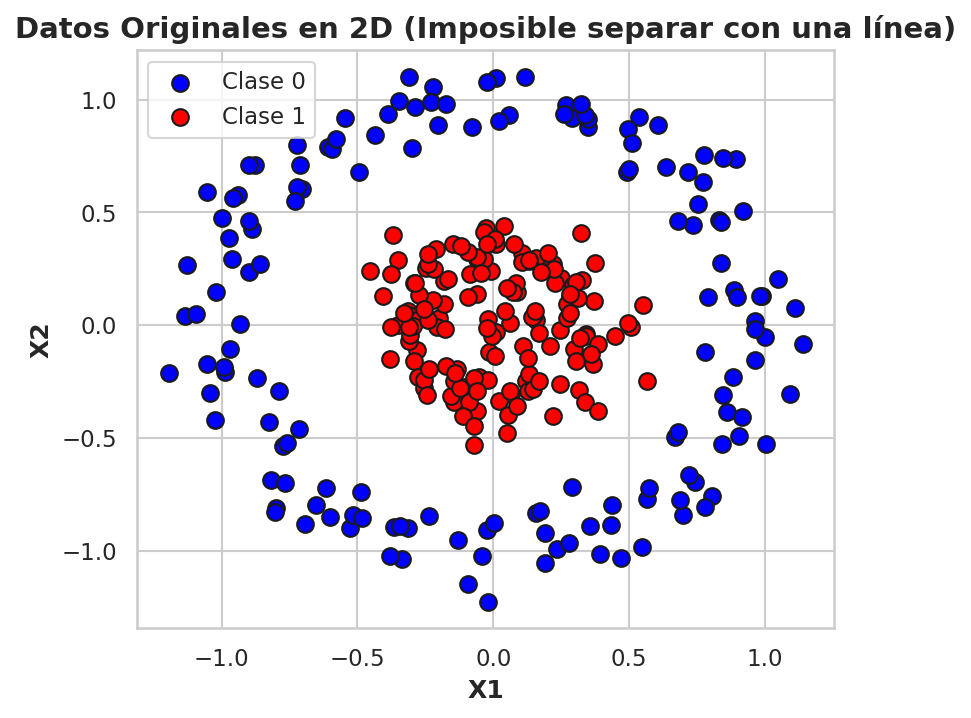

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from mpl_toolkits.mplot3d import Axes3D

# 1. Generamos datos circulares (no separables linealmente en 2D)
X_circ, y_circ = make_circles(n_samples=300, factor=0.3, noise=0.1, random_state=42)

# 2. Visualizamos el problema en 2D
plt.figure(figsize=(6, 5))
plt.scatter(X_circ[y_circ==0, 0], X_circ[y_circ==0, 1], color='blue', label='Clase 0', edgecolors='k')
plt.scatter(X_circ[y_circ==1, 0], X_circ[y_circ==1, 1], color='red', label='Clase 1', edgecolors='k')
plt.title("Datos Originales en 2D (Imposible separar con una línea)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


Si intentáramos usar una Regresión Logística aquí, fallaría miserablemente (su *Accuracy* rondaría el 50%, equivalente a lanzar una moneda).

Ahora, vamos a aplicar manualmente una transformación matemática para elevar los datos a 3D, simulando lo que hace el Kernel RBF (*Radial Basis Function*) internamente.



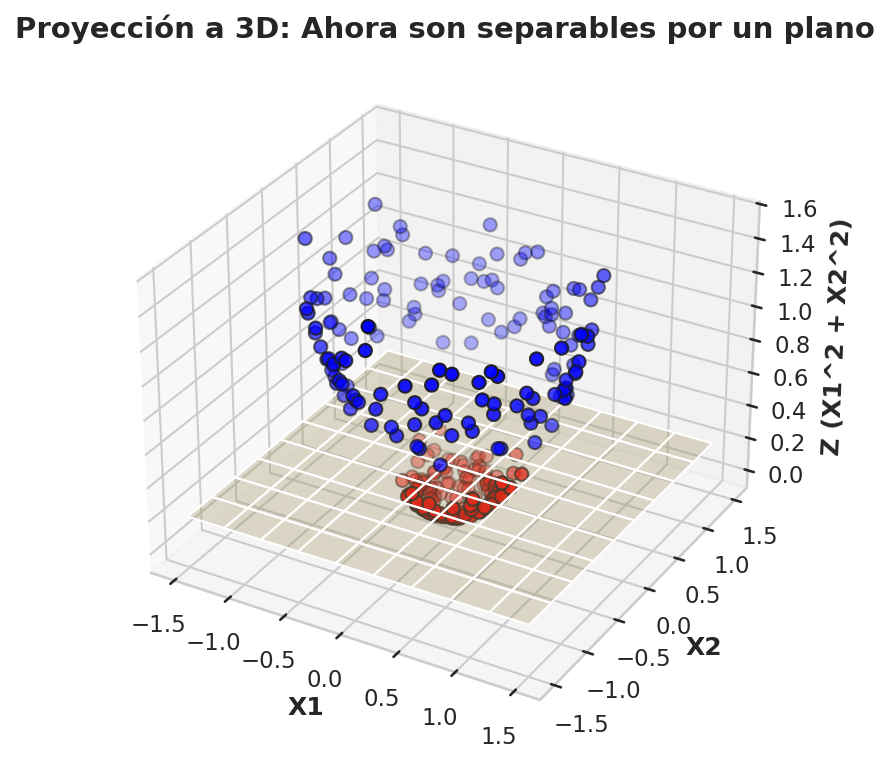

In [ ]:
# 3. Elevamos los datos a 3D creando una nueva característica Z
# Z será la distancia al cuadrado desde el origen (x1^2 + x2^2)
Z = X_circ[:, 0]**2 + X_circ[:, 1]**2

# Visualizamos en 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_circ[y_circ==0, 0], X_circ[y_circ==0, 1], Z[y_circ==0], color='blue', edgecolors='k', s=40)
ax.scatter(X_circ[y_circ==1, 0], X_circ[y_circ==1, 1], Z[y_circ==1], color='red', edgecolors='k', s=40)

# Dibujamos un plano separador (hiperplano)
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 10), np.linspace(-1.5, 1.5, 10))
zz = np.full(xx.shape, 0.2) # Plano a la altura Z=0.2
ax.plot_surface(xx, yy, zz, alpha=0.3, color='y')

ax.set_title("Proyección a 3D: Ahora son separables por un plano")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Z (X1^2 + X2^2)")
plt.show()


En la práctica, no hacemos esta transformación manual. Simplemente le decimos a Scikit-Learn que use un `kernel='rbf'` y el algoritmo encuentra la frontera curva óptima en el espacio 2D original.



### El Talón de Aquiles: Complejidad Computacional



Si SVM con Kernel RBF es tan poderoso y encuentra la frontera óptima, ¿por qué no lo usamos siempre? ¿Por qué fue desplazado por el Deep Learning y los ensambles de árboles (XGBoost) en la última década?

La respuesta es puramente de ingeniería: **El costo de entrenamiento**.

Para encontrar los Vectores de Soporte, el algoritmo debe resolver un problema de optimización cuadrática. La complejidad temporal de entrenar un SVM estándar escala entre $O(n^2)$ y $O(n^3)$, donde $n$ es el número de muestras.

Vamos a demostrar esto empíricamente usando nuestro **Body Measurements Dataset (BMD)**. Para ello, entrenamos SVMs incrementando artificialmente el tamaño del dataset y medimos el tiempo del entrenamiento.



Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/bmd/datos_bmd.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 716 filas y 13 columnas.


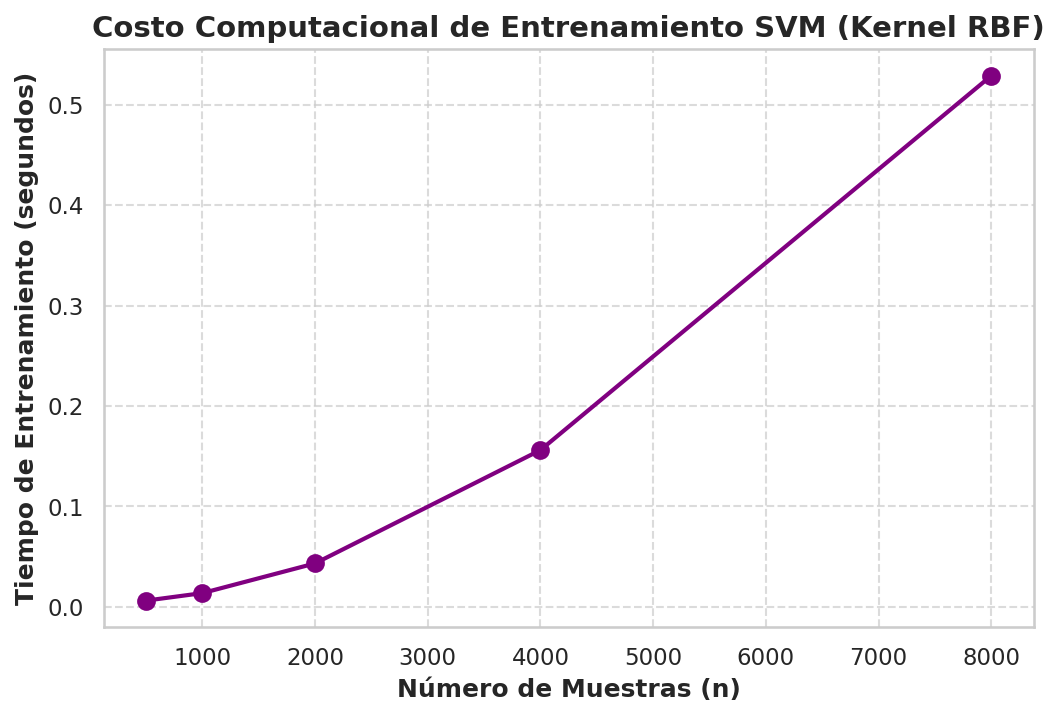

In [6]:
import time
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset real
dataset_path = "datasets/bmd/datos_bmd.csv"
df = load_dataset(dataset_path)
df['es_adulto'] = (df['Edad'] >= 18).astype(int)
X = df.drop(columns=['Edad', 'Genero', 'es_adulto'])
y = df['es_adulto']

# Escalamos (SVM, al igual que KNN, es extremadamente sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simulamos datasets de diferentes tamaños duplicando los datos
tamanos = [500, 1000, 2000, 4000, 8000]
tiempos_entrenamiento = []

for n in tamanos:
    # Muestreamos con reemplazo para simular un dataset más grande
    indices = np.random.choice(len(X_scaled), n, replace=True)
    X_subset = X_scaled[indices]
    y_subset = y.iloc[indices]

    svm_clf = SVC(kernel='rbf', C=1.0)

    start_time = time.time()
    svm_clf.fit(X_subset, y_subset)
    end_time = time.time()

    tiempos_entrenamiento.append(end_time - start_time)

# Visualizamos el crecimiento del tiempo
plt.figure(figsize=(8, 5))
plt.plot(tamanos, tiempos_entrenamiento, marker='o', linestyle='-', color='purple', linewidth=2)
plt.title("Costo Computacional de Entrenamiento SVM (Kernel RBF)")
plt.xlabel("Número de Muestras (n)")
plt.ylabel("Tiempo de Entrenamiento (segundos)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Resultados y Discusión



Observar la curva del gráfico superior. No es una línea recta (crecimiento lineal $O(n)$), sino una curva exponencial.

Si se duplica la cantidad de datos, el tiempo de entrenamiento no se duplica; se multiplica por 4 o incluso por 8.
- Para `1000` registros, tarda fracciones de segundo.
- Para `100000` registros, podría tardar horas.
- Para `1000000` de registros (algo común hoy en día), podría tardar **semanas** o simplemente agotar la memoria RAM del servidor.

**Criterio de Ingeniería:**
SVM fue el "rey" del Machine Learning en los años 90 y principios de los 2000, cuando los datasets típicos tenían unos pocos miles de registros. Hoy en día, para datos tabulares masivos, preferimos algoritmos que escalen linealmente $O(n)$ o $O(n \log n)$, como los ensambles de árboles (Random Forest, XGBoost) o Redes Neuronales.

Sin embargo, SVM sigue siendo una herramienta excepcional para:
1. Datasets pequeños o medianos (menos de `50000` muestras) donde la relación entre variables es altamente no lineal.
2. Problemas donde el número de características (columnas) es mayor que el número de muestras (filas), como en el análisis de microarrays de ADN en bioinformática.



## Conexiones y Próximos Pasos


Hemos explorado los enfoques probabilísticos (Regresión Logística), basados en memoria (KNN) y geométricos (SVM). Todos ellos requieren que los datos estén estrictamente escalados y son, en cierta medida, "cajas negras" matemáticas.

Pero, ¿qué pasa si el departamento legal o médico de una empresa te exige explicar **exactamente por qué** el modelo tomó una decisión?

- ➡️ **Siguiente:** En el notebook [Clasificación con Árboles y Reglas](04_clasificacion_arboles_y_reglas.ipynb), abandonamos las matemáticas continuas para entrar en el mundo de la lógica discreta. Veremos cómo los Árboles de Decisión dividen el espacio usando reglas *If-Else* perfectamente interpretables por humanos.
- 🔄 **Relacionado:** Para entender cómo mitigar el alto costo de entrenamiento de modelos complejos, revisamos técnicas de reducción de dimensionalidad en los notebooks [Selección de Variables y Prototipado Rápido (AutoML)](10_seleccion_variables_y_automl.ipynb) y/o [Reducción de Dimensionalidad: PCA y Reconstrucción](11_pca_y_reconstruccion.ipynb).

## Referencias


1. Cortes, C., & Vapnik, V. (1995). *Support-vector networks*. Machine learning, 20(3), 273-297.
2. [Scikit-Learn: Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html)

---


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
